# Out-of-sample validation of the seasonal chain

The calibration is judged so far on the very days it was fitted to. This notebook checks it on
days set aside. The seasonal chain of V3 (steps 4 to 7) is run unchanged on one part of the
days, and the retained model is judged on the other part, with the same validation contract.

Two splits of the days kept by DBSCAN:

- **weeks**: even calendar weeks (counted from Monday 1 January 2024) for the calibration, odd
  weeks for the test; 35 targets (0152GBO rainy season left out: 11 days, too few for two halves);
- **years**: first campaign year of the season for the calibration, last one for the test;
  10 targets, those observed over two years.

The reference is the gap between the two measured parts themselves. A model cannot be closer
to the test days than the calibration days are, so a test error close to that gap means the
model has learnt the appliance, not the noise of its calibration days.

Code: `src/holdout.py`. Results: `resultats/holdout/` (weeks) and `resultats/holdout_annee/`
(years).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve().parents[1]      # repository root, two levels above notebooks/validation/
SPLITS = {"weeks": REPO / "resultats" / "holdout", "years": REPO / "resultats" / "holdout_annee"}
tables = {name: pd.read_csv(folder / "validation_hors_echantillon.csv") for name, folder in SPLITS.items()}


def summary(t):
    """Key figures of one split: NRMSE at calibration, at test and between the measured parts, energy gap."""
    ratio = t.NRMSE_test / t.NRMSE_moities
    return {
        "targets": len(t),
        "NRMSE calibration, mean": f"{100 * t.NRMSE_calage.mean():.1f} %",
        "NRMSE test, mean (median, max)":
            f"{100 * t.NRMSE_test.mean():.1f} % ({100 * t.NRMSE_test.median():.1f} %, {100 * t.NRMSE_test.max():.1f} %)",
        "NRMSE between measured parts, mean":
            f"{100 * t.NRMSE_moities.mean():.1f} %",
        "test / between parts, median": f"{ratio.median():.2f}",
        "energy gap at test, mean of absolute values (max)":
            f"{t.err_E_pct_test.abs().mean():.1f} % ({t.err_E_pct_test.abs().max():.1f} %)",
    }


pd.DataFrame({name: summary(t) for name, t in tables.items()})

,weeks,years
targets,35,10
"NRMSE calibration, mean",9.2 %,8.7 %
"NRMSE test, mean (median, max)","20.6 % (19.4 %, 43.4 %)","34.8 % (23.6 %, 149.9 %)"
"NRMSE between measured parts, mean",20.5 %,35.3 %
"test / between parts, median",1.00,0.97
"energy gap at test, mean of absolute values (max)",18.7 % (80.6 %),58.5 % (213.5 %)


At test the NRMSE rises from about 9 % to about 21 % (weeks) and 35 % (years), but the two
measured parts already differ by as much: the median ratio of the test error to that gap is 1.00
and 0.97. The test error is thus of the size of the difference between the measured parts
themselves.

## Target by target

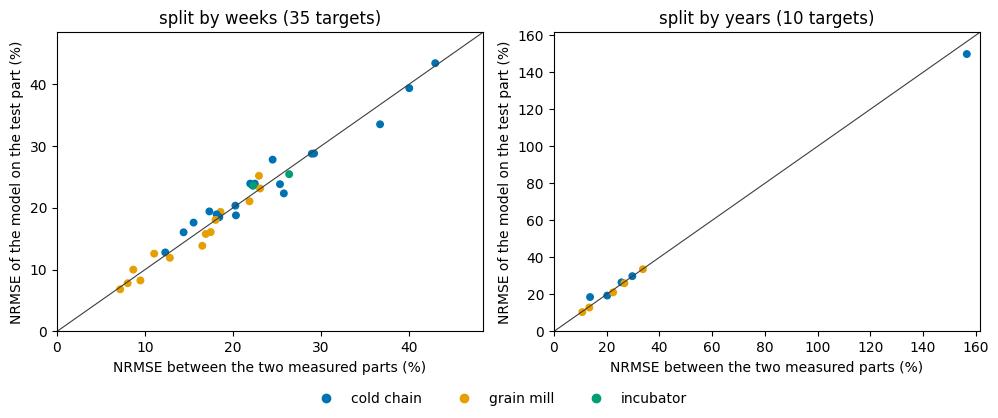

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, (name, t) in zip(axes, tables.items()):
    colour = t.famille.map({"cold_chain": "#0072B2", "grain_milling": "#E69F00", "poultry_incubation": "#009E73"})
    ax.scatter(100 * t.NRMSE_moities, 100 * t.NRMSE_test, c=colour, s=22)
    top = 5 + 100 * max(t.NRMSE_moities.max(), t.NRMSE_test.max())
    ax.plot([0, top], [0, top], color="#3D3D3D", lw=0.8)
    ax.set_xlim(0, top)
    ax.set_ylim(0, top)
    ax.set_xlabel("NRMSE between the two measured parts (%)")
    ax.set_ylabel("NRMSE of the model on the test part (%)")
    ax.set_title(f"split by {name} ({len(t)} targets)")
handles = [plt.Line2D([], [], marker="o", ls="none", color=c, label=f)
           for f, c in (("cold chain", "#0072B2"), ("grain mill", "#E69F00"), ("incubator", "#009E73"))]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

Points on the diagonal: the model misses the test days by exactly as much as the two measured
parts differ. The year split has the largest gaps: the use of some appliances changed from one
year to the next (0151GBO rainy season since September 2025, 11 calibration days only: NRMSE of 156.6 %
between the two measured parts).

## Verdicts of the validation contract

In [3]:
verdicts = {}
for name, t in tables.items():
    verdicts[f"{name}, calibration part"] = t.verdict_calage.value_counts()
    verdicts[f"{name}, test part"] = t.verdict_test.value_counts()
pd.DataFrame(verdicts).fillna(0).astype(int).reindex(["validee", "rejetee", "non verifiable"])

,"weeks, calibration part","weeks, test part","years, calibration part","years, test part"
validee,4,0,1,0
rejetee,9,15,6,8
non verifiable,22,20,3,2


No target is validated on its test part: half as many days stand behind each part, so most
targets become *not verifiable* (too few or too scattered days for any model, even a perfect one,
to be judged at the 10 % level), and the others are rejected.

Detail of one split, one row per target:

In [4]:
columns = ["cible", "famille", "jours_calage", "jours_test", "NRMSE_calage", "NRMSE_test", "NRMSE_moities",
           "err_E_pct_test", "verdict_test"]
tables["weeks"][columns].round(3)

,cible,famille,jours_calage,jours_test,NRMSE_calage,NRMSE_test,NRMSE_moities,err_E_pct_test,verdict_test
0,0016GBO__Mai,grain_milling,13,16,0.119,0.252,0.230,79.808,non verifiable
1,0016GBO__Saison_des_pluies,grain_milling,18,17,0.257,0.194,0.186,-80.602,non verifiable
2,0016GBO__Saison_seche,grain_milling,52,62,0.082,0.161,0.175,-0.680,rejetee
3,0017SAM__Mai_avant_2025-09-25,cold_chain,14,17,0.131,0.335,0.367,-32.491,non verifiable
4,0017SAM__Octobre_depuis_2025-09-25,cold_chain,14,12,0.071,0.185,0.185,-35.841,non verifiable
5,0017SAM__Saison_des_pluies_avant_2025-09-25,cold_chain,38,41,0.090,0.278,0.245,6.347,non verifiable
6,0017SAM__Saison_seche_avant_2025-09-25,cold_chain,36,36,0.080,0.288,0.292,-27.051,non verifiable
7,0017SAM__Saison_seche_depuis_2025-09-25,cold_chain,67,65,0.094,0.188,0.203,-1.421,non verifiable
8,0018SAM__Octobre_depuis_2025-10-02,cold_chain,14,12,0.154,0.394,0.400,-20.909,non verifiable
9,0018SAM__Saison_seche_avant_2025-10-02,cold_chain,55,52,0.079,0.236,0.222,-11.688,non verifiable


To run the check again (about eleven hours for the weeks and one hour for the years, on 15
processors):

```
cd src
python holdout.py --split semaines
python holdout.py --split annees
```